In [1]:
import numpy as np
import sympy as sp
from matplotlib import pyplot
from sympy.utilities.lambdify import lambdify

sp.init_printing(use_latex=True)

t, x, nu = sp.symbols('t x nu')
phi = sp.exp((-(x - 4*t)**2) / (4 * nu * (t + 1))) + sp.exp((-(x - 4 * t -2 * sp.pi)**2) / (4 * nu * (t + 1)))

phiprime = phi.diff(x)

u_analytical = - ((2 * nu / phi) * phiprime) + 4

ufunc = lambdify((t, x, nu), u_analytical)

In [2]:
# plotting analytical solution

# define domain and nx to calculate x afterwards using both of them
domain = 2 * np.pi
nx = 401

t = 0
x = np.linspace(0, domain, nx)
nu = 0.07

u_analytical = ufunc(t, x, nu)
# u_test = np.asarray([ufunc(t, x0, nu) for x0 in x])


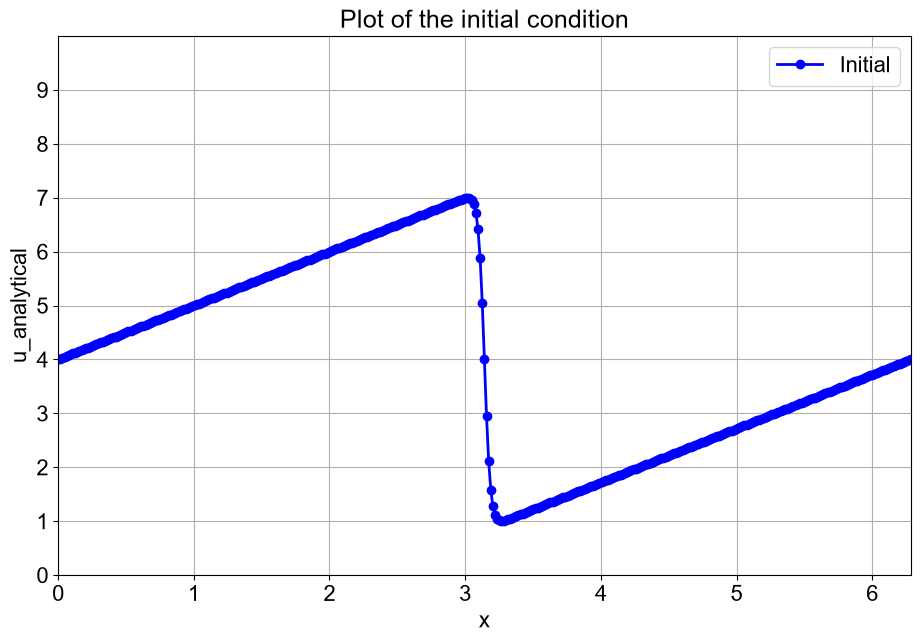

In [3]:
pyplot.rcParams['font.family'] = 'arial'
pyplot.rcParams['font.size'] = 16

pyplot.figure(figsize=(11, 7), dpi = 100)

pyplot.plot(x, u_analytical, color='blue', linewidth=2, marker='o', label='Initial')

pyplot.xlabel('x', fontsize=16)
pyplot.ylabel('u_analytical', fontsize=16)

pyplot.title('Plot of the initial condition', fontsize=18)

pyplot.grid(True)

pyplot.legend(loc='upper right')

pyplot.xlim([0, 2*np.pi])
pyplot.ylim([0, 10])

pyplot.xticks(np.arange(0, 2*np.pi, 1))
pyplot.yticks(np.arange(0, 10, 1))

pyplot.show()

In [4]:
# numerically solving burgers' equation

domain = 2 * np.pi
nx = 401
nt = 100
dx = domain / (nx - 1)
nu = 0.07
dt = nu * dx
t = nt * dt

u = ufunc(0, x, nu) # ufunc at time = 0 (initial condition/state of function)

for n in range(nt):
    un = u.copy()
    u[1:-1] = (un[1:-1] - un[1:-1] * (dt/dx) * (un[1:-1] - un[:-2]) +
    (nu * dt / (dx)**2) * (un[:-2] - 2*un[1:-1] + un[2:])) 
    
    # periodic boundary conditions
    u[-1] = (un[-1] - un[-1] * (dt/dx) * (un[-1] - un[-2]) +
    (nu * dt / (dx)**2) * (un[-2] - 2*un[-1] + un[1]))
    # the above line is for the last point in the array
    # which is updated using the second last point u[-2] as left neighbor
    # and the first point u[1] as right neighbor
    u[0] = u[-1]


u_analytical = ufunc(t, x, nu)

# ^ analytical u at time t = nt * dt not at t = 0 going to graph it for comparison

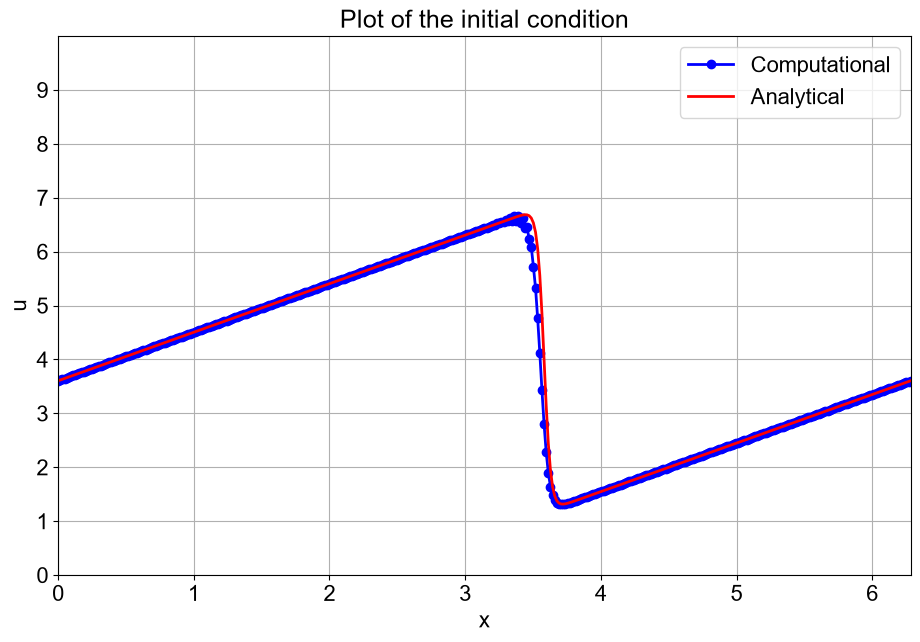

In [5]:
pyplot.rcParams['font.family'] = 'arial'
pyplot.rcParams['font.size'] = 16

pyplot.figure(figsize=(11, 7), dpi = 100)

pyplot.plot(x, u, color='blue', linewidth=2, marker='o', label='Computational')
pyplot.plot(x, u_analytical, color='red', linewidth=2, label='Analytical')


pyplot.xlabel('x', fontsize=16)
pyplot.ylabel('u', fontsize=16)

pyplot.title('Plot of the initial condition', fontsize=18)

pyplot.grid(True)

pyplot.legend(loc='upper right')

pyplot.xlim([0, 2*np.pi])
pyplot.ylim([0, 10])

pyplot.xticks(np.arange(0, 2*np.pi, 1))
pyplot.yticks(np.arange(0, 10, 1))

pyplot.show()